<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-performance-analysis-ml-98-87?scriptVersionId=271179220" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance/StudentPerformance.csv


## Student Performance Analysis

## Description:
This dataset focuses on analyzing various factors that influence students' academic performance. It includes features such as study habits, lifestyle choices, and psychological aspects that may affect learning outcomes. The goal is to identify patterns and relationships between these factors and overall student performance, helping educators and researchers understand key contributors to academic success and areas that need improvement.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/student-performance/StudentPerformance.csv")

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [8]:
df.duplicated().sum()

127

In [9]:
df.nunique()

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [10]:
df.shape

(10000, 6)

In [11]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [12]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

## Data visualizations

In [13]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (10000, 6)

First 5 Rows:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [14]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000

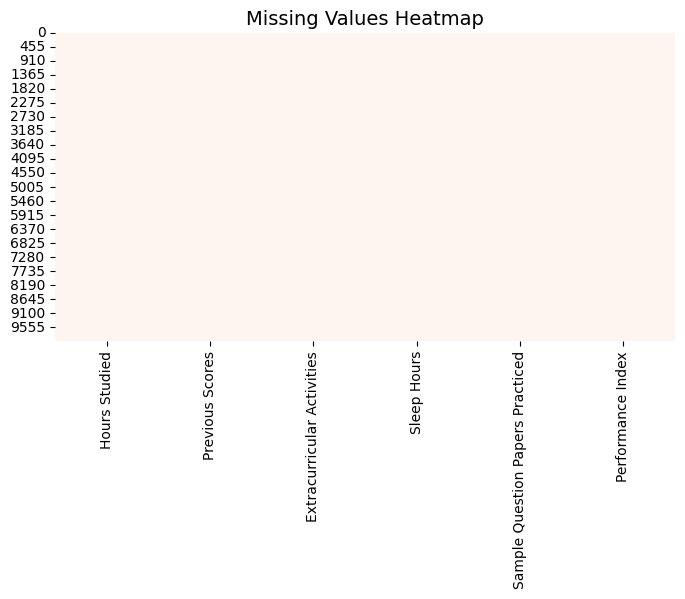

In [15]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

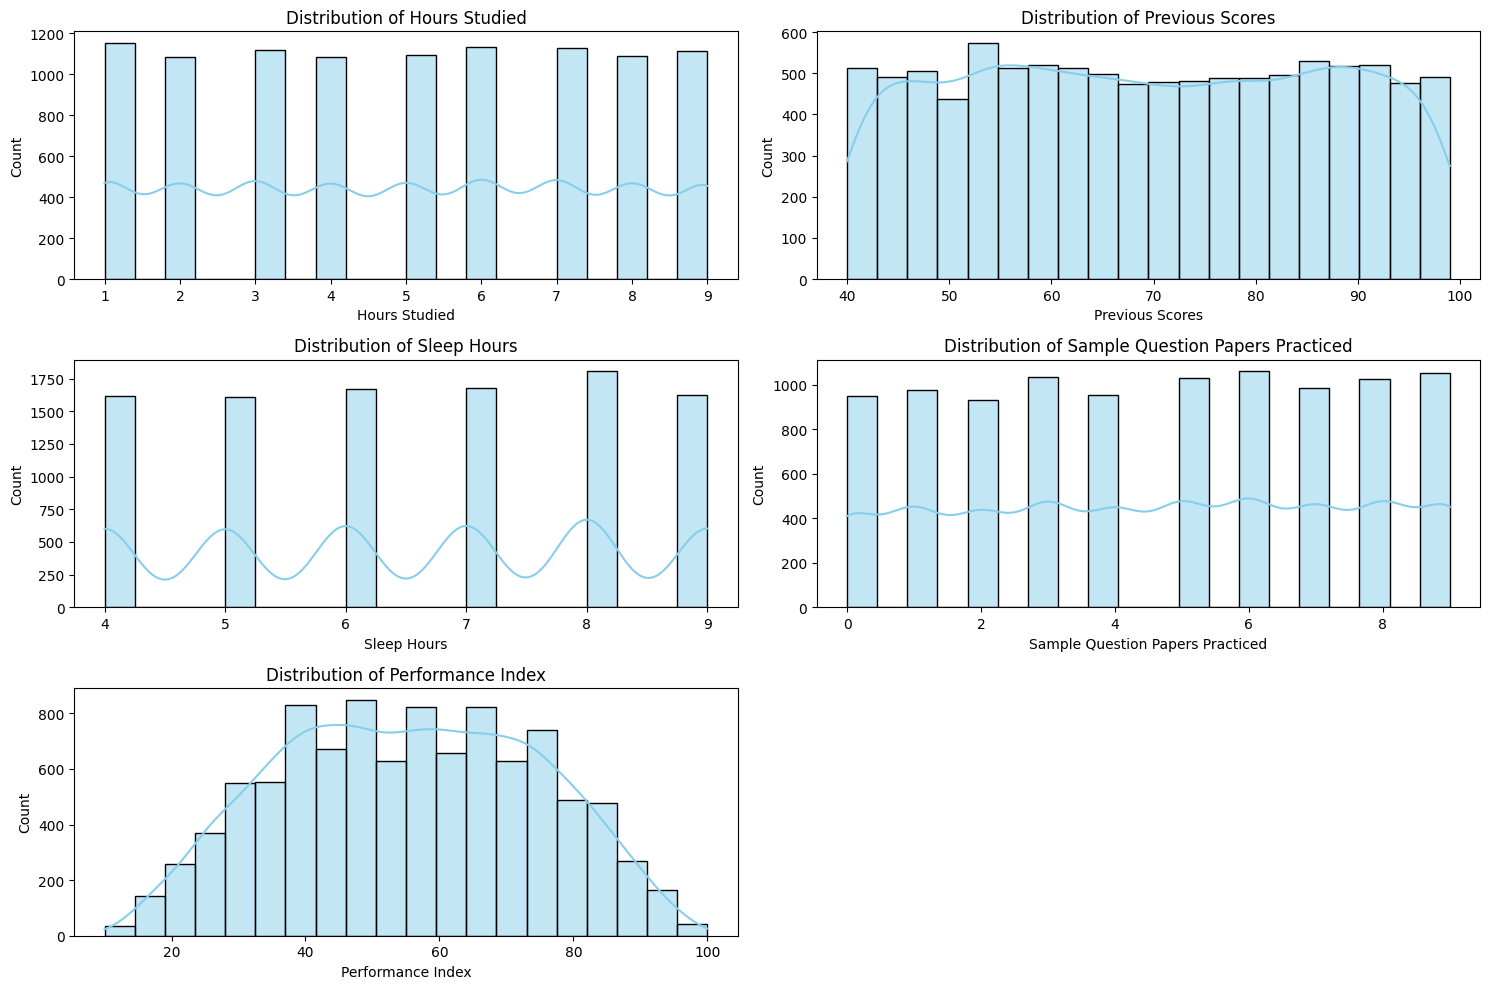

In [16]:
num_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue', bins=20)
    plt.title(f"Distribution of {col}", fontsize=12)
plt.tight_layout()
plt.show()

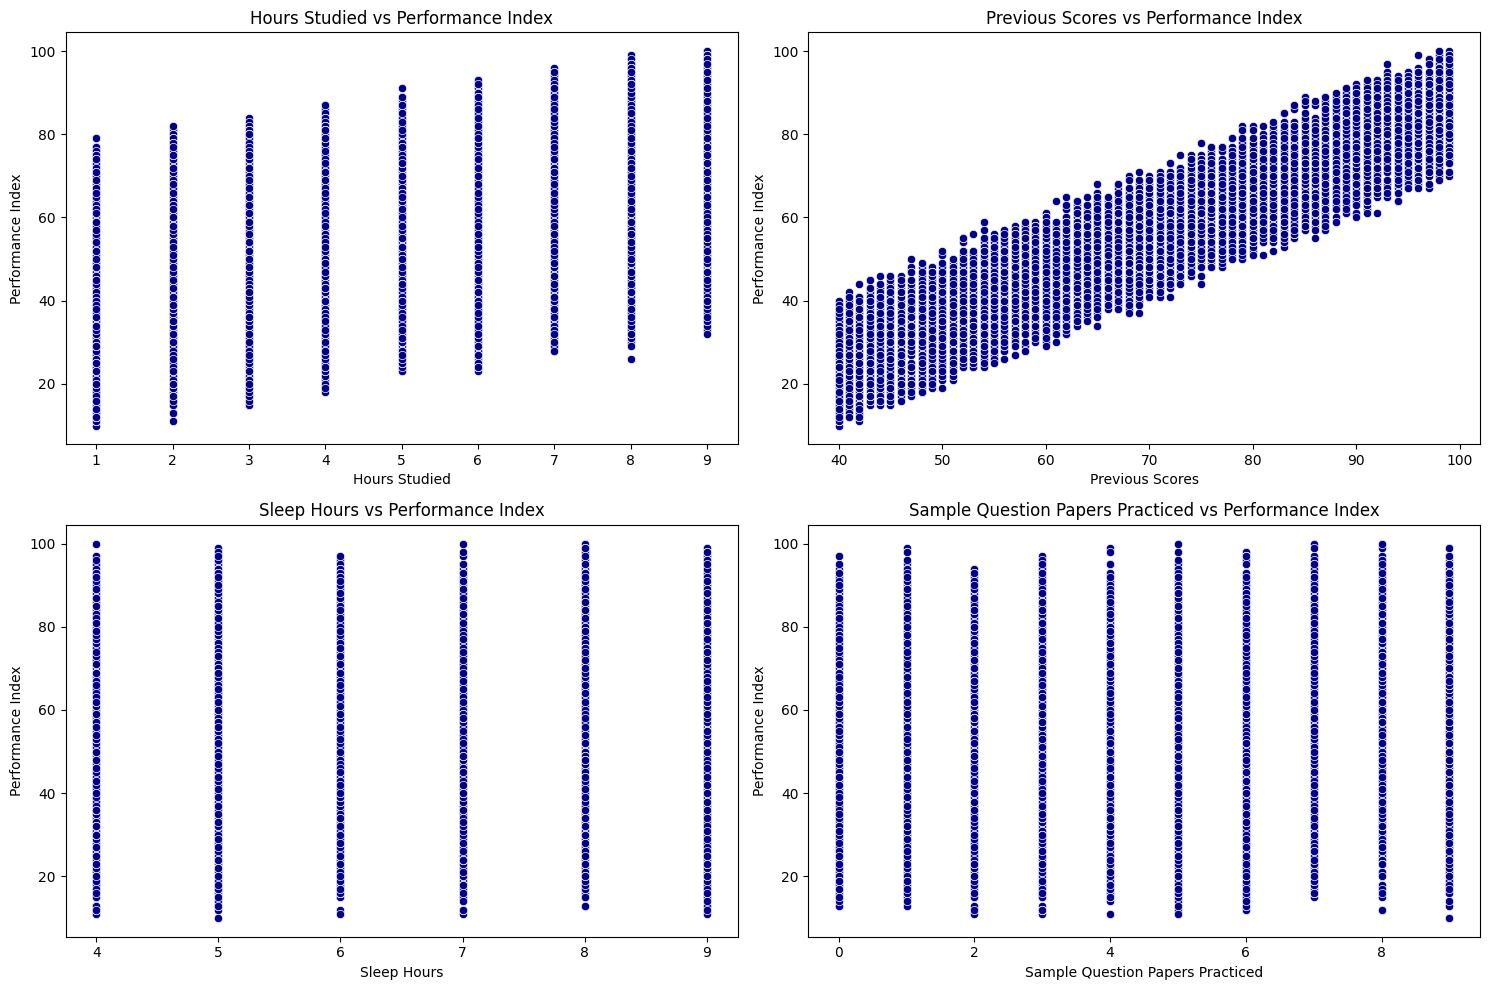

In [17]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features[:-1], 1):  # exclude target itself
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[col], y=df['Performance Index'], color='darkblue')
    plt.title(f"{col} vs Performance Index", fontsize=12)
plt.tight_layout()
plt.show()


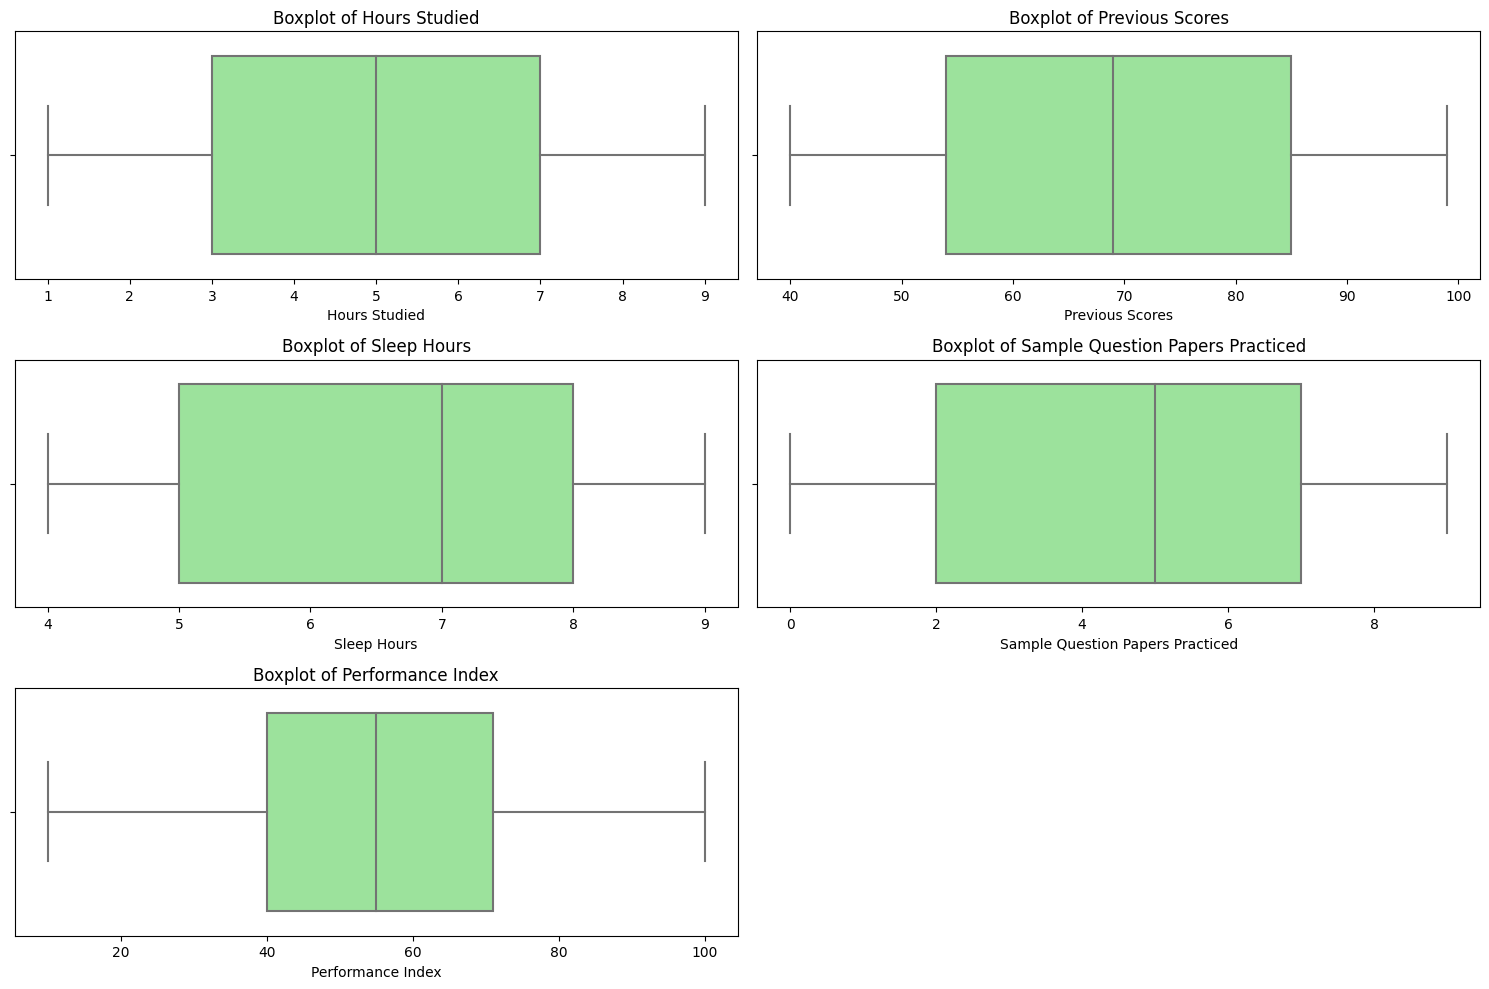

In [18]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}", fontsize=12)
plt.tight_layout()
plt.show()

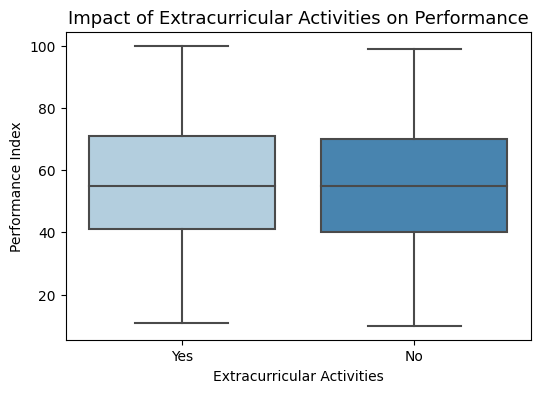

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df, palette='Blues')
plt.title("Impact of Extracurricular Activities on Performance", fontsize=13)
plt.show()

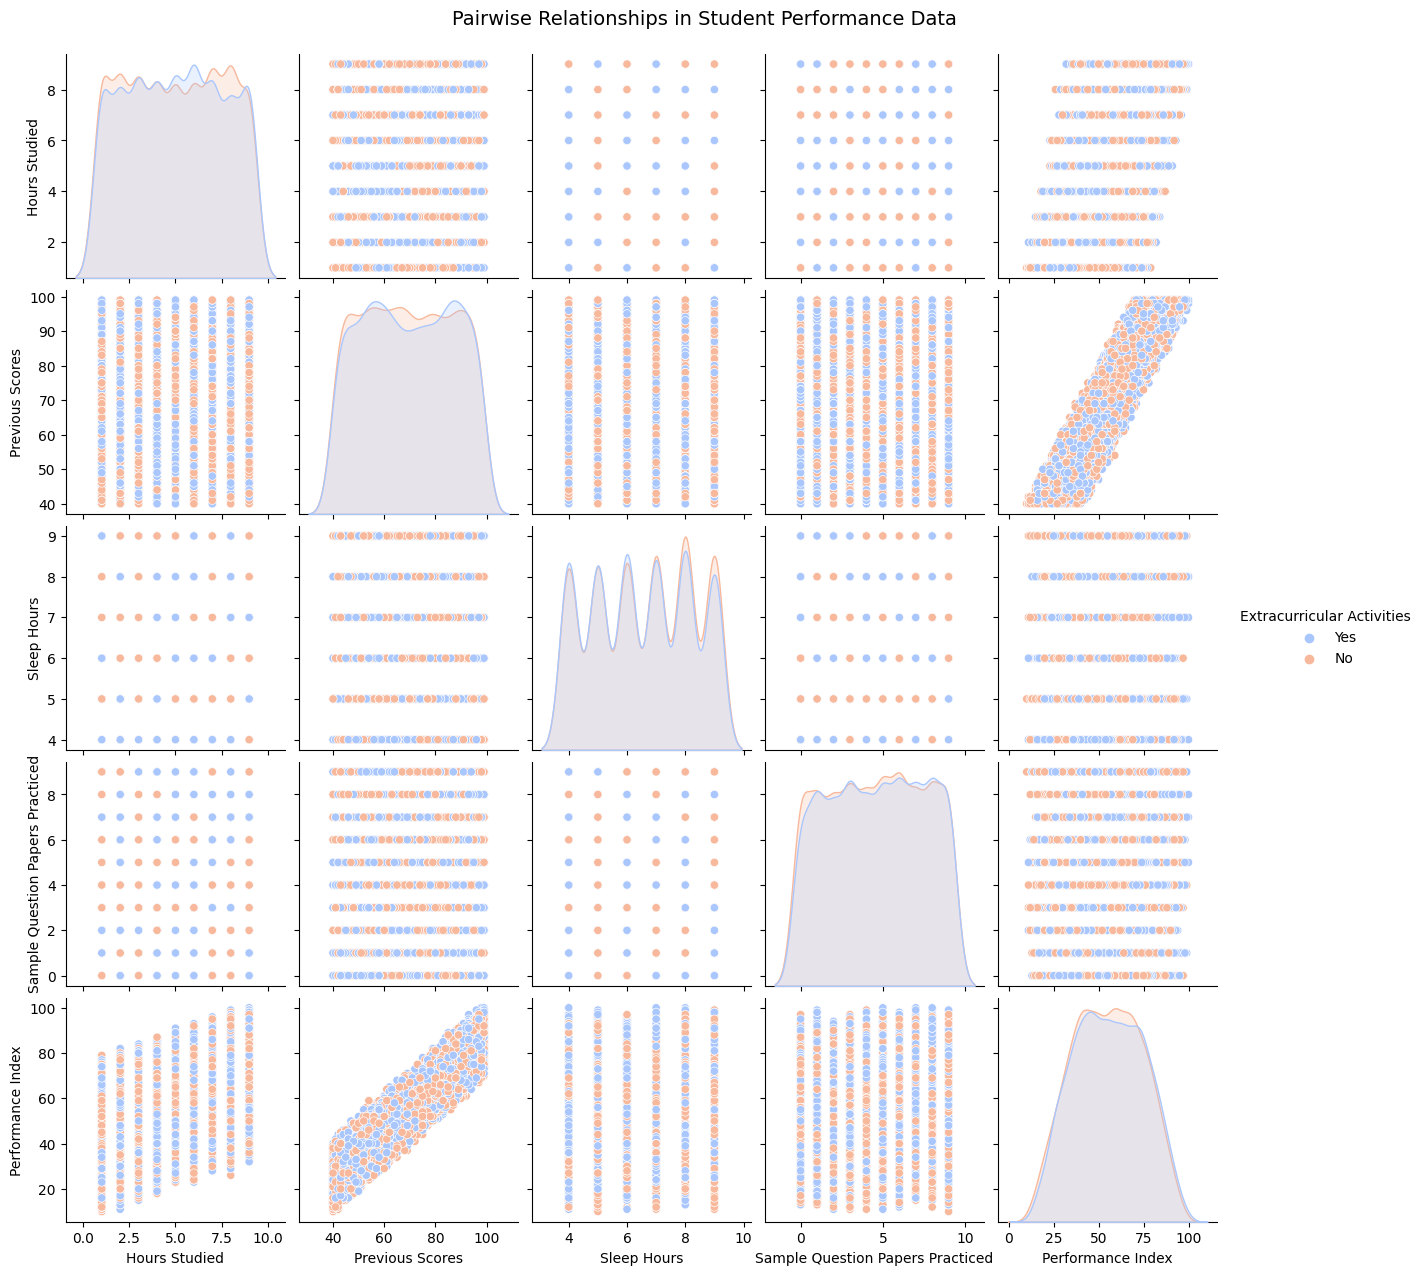

In [20]:
sns.pairplot(df, hue='Extracurricular Activities', palette='coolwarm')
plt.suptitle("Pairwise Relationships in Student Performance Data", y=1.02, fontsize=14)
plt.show()

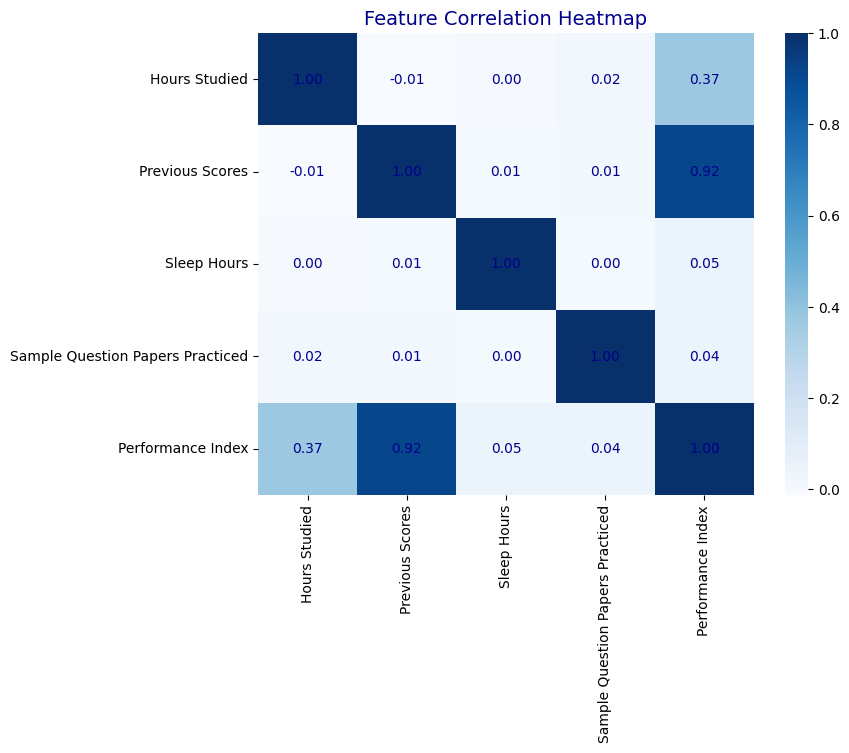

In [21]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)  # only numeric columns
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f",
            annot_kws={"size": 10, "color": "darkblue"})
plt.title("Feature Correlation Heatmap", fontsize=14, color='darkblue')
plt.show()


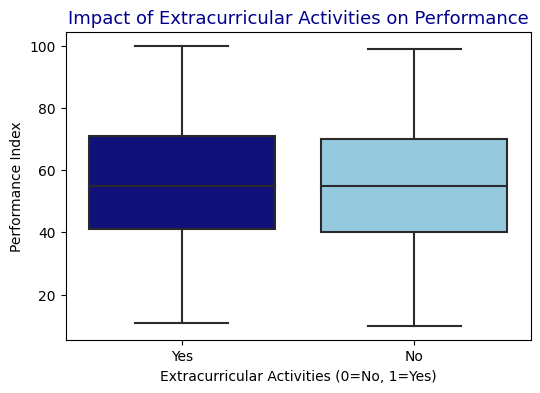

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df,
            palette=['darkblue', 'skyblue'])
plt.title("Impact of Extracurricular Activities on Performance", fontsize=13, color='darkblue')
plt.xlabel("Extracurricular Activities (0=No, 1=Yes)")
plt.show()

## ML Algorithms

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
target = 'Performance Index'

In [25]:
model_df = df[features + [target]].dropna()

# Split into train/test
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.01),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}


In [27]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        "MSE": mse,
        "R2_Score": r2 * 100  # convert to %
    }
    print(f"{name}: MSE = {mse:.2f}, R² = {r2*100:.2f}%")


Linear Regression: MSE = 4.18, R² = 98.87%
Lasso Regression: MSE = 4.18, R² = 98.87%
Ridge Regression: MSE = 4.18, R² = 98.87%
Random Forest: MSE = 5.38, R² = 98.55%
Gradient Boosting: MSE = 4.45, R² = 98.80%
Support Vector Regressor: MSE = 5.34, R² = 98.56%


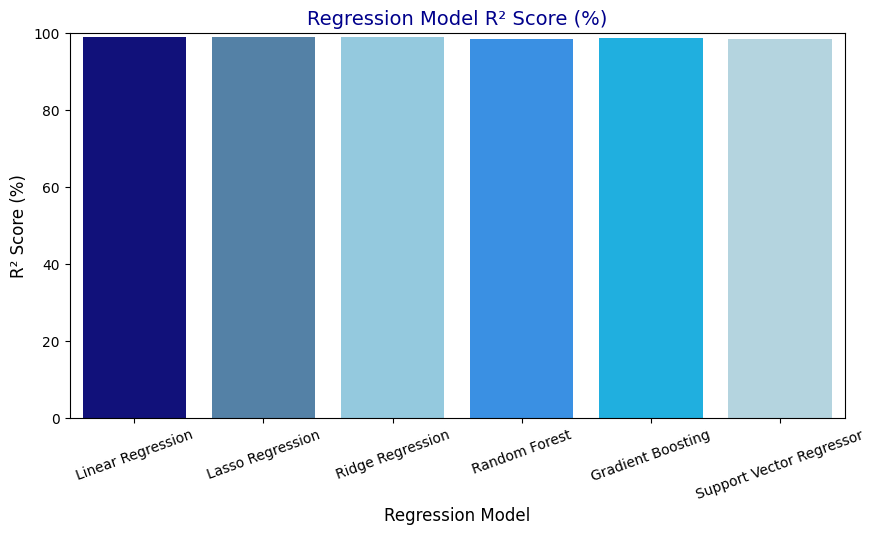

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(results.keys()),
    y=[r["R2_Score"] for r in results.values()],
    palette=['darkblue', 'steelblue', 'skyblue', 'dodgerblue', 'deepskyblue', 'lightblue']
)
plt.title("Regression Model R² Score (%)", fontsize=14, color='darkblue')
plt.ylabel("R² Score (%)", fontsize=12)
plt.xlabel("Regression Model", fontsize=12)
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

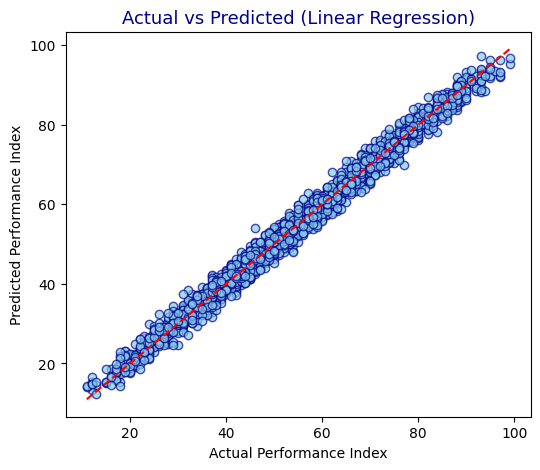

In [29]:
best_model_name = max(results, key=lambda x: results[x]["R2_Score"])
best_model = models[best_model_name]
y_best_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_best_pred, color='skyblue', edgecolor='darkblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Actual vs Predicted ({best_model_name})", fontsize=13, color='darkblue')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.show()

In [30]:
print(f"\n🏆 Best Performing Model: {best_model_name} with R² = {results[best_model_name]['R2_Score']:.2f}%")


🏆 Best Performing Model: Linear Regression with R² = 98.87%


## Thank you...pls upvote!!!